In [2]:
# 7-13-2026

In [7]:
import xarray as xr
import numpy as np
import pandas as pd
import regionmask
import matplotlib.pyplot as plt

In [4]:
zarr_path = "seasfire_pyromes_ecoregions.zarr"

In [5]:
ds = xr.open_zarr(zarr_path, consolidated=True)

In [6]:
list(ds.data_vars)

['area',
 'biomes',
 'cams_co2fire',
 'cams_frpfire',
 'drought_code_max',
 'drought_code_mean',
 'ecoregion',
 'fcci_ba',
 'fcci_ba_valid_mask',
 'fcci_fraction_of_burnable_area',
 'fcci_fraction_of_observed_area',
 'fcci_number_of_patches',
 'fwi_max',
 'fwi_mean',
 'gwis_ba',
 'gwis_ba_valid_mask',
 'lai',
 'lccs_class_1',
 'lccs_class_2',
 'lccs_class_3',
 'lccs_class_4',
 'lccs_class_6',
 'lccs_class_7',
 'lsm',
 'lst_day',
 'ndvi',
 'pop_dens',
 'pyrome',
 'rel_hum',
 'skt',
 'ssr',
 'ssrd',
 'sst',
 'swvl1',
 'swvl2',
 'swvl3',
 'swvl4',
 't2m_max',
 't2m_mean',
 't2m_min',
 'tp',
 'vpd',
 'ws10']

In [9]:
pyromes = ds["pyrome"]

In [17]:
vals, counts = np.unique(pyromes.values, return_counts=True)
dict(zip(vals, counts))

{np.uint8(1): np.int64(10504),
 np.uint8(2): np.int64(34500),
 np.uint8(3): np.int64(25708),
 np.uint8(4): np.int64(24084),
 np.uint8(5): np.int64(14412),
 np.uint8(255): np.int64(927592)}

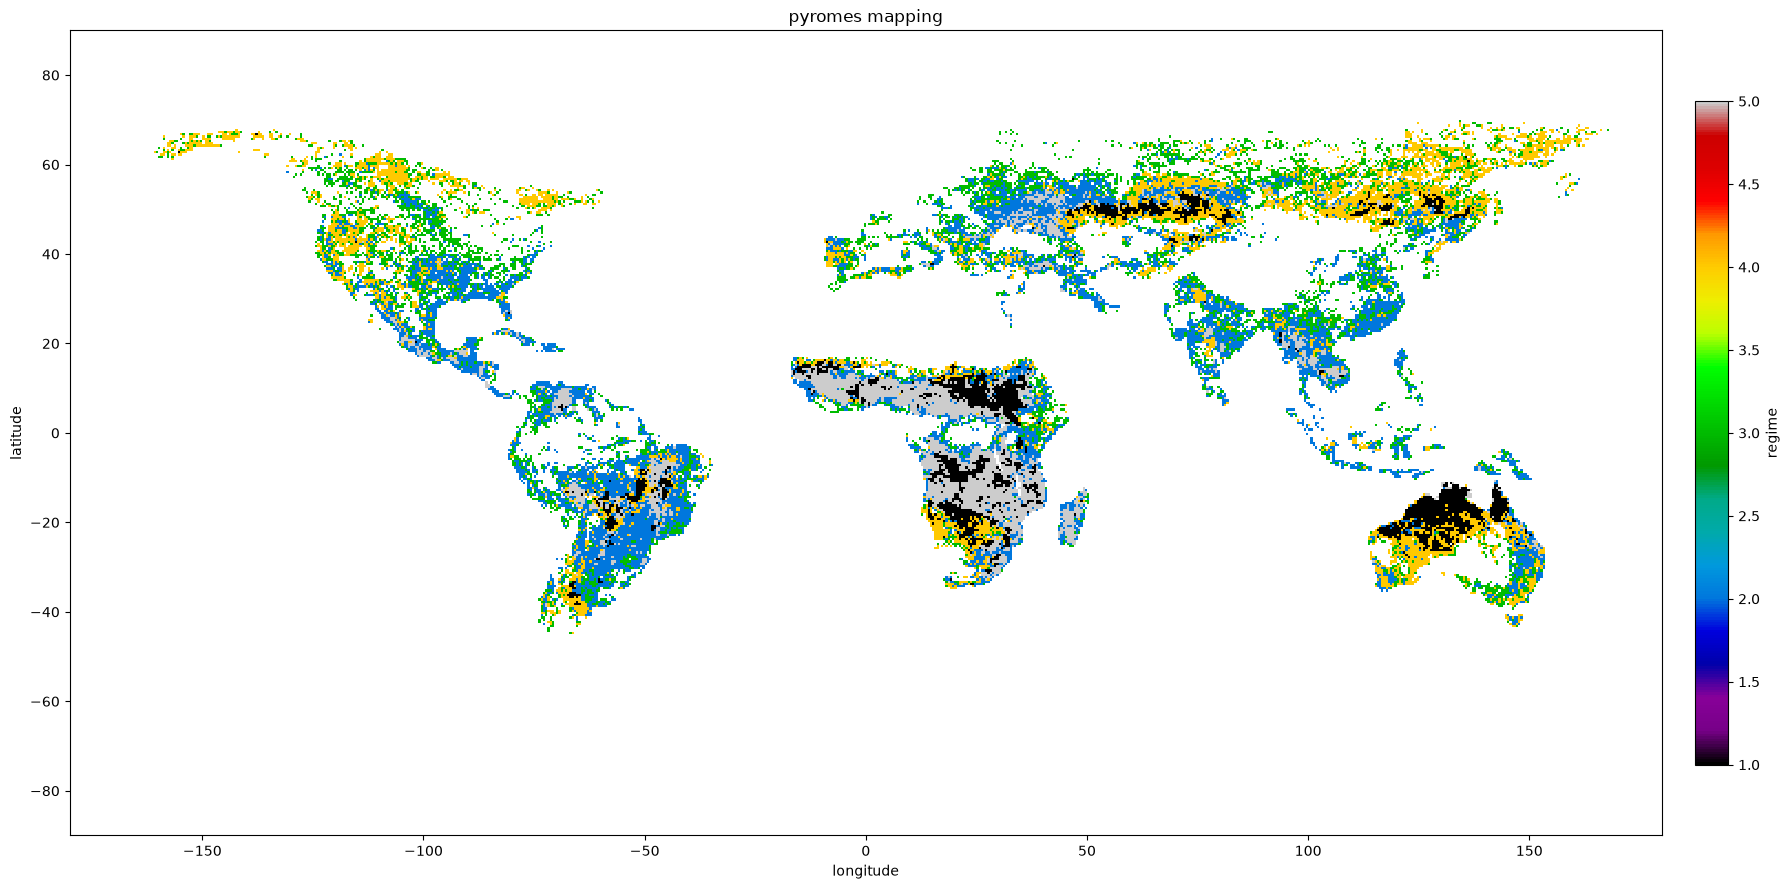

In [18]:
data = pyromes.values.astype(float)
data[data == 255] = np.nan  # replace fill value with nan

cmap = plt.cm.nipy_spectral.copy()
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(18, 9))

img = ax.imshow(
    data,
    origin="upper",
    extent=[-180, 180, -90, 90],
    cmap=cmap,
    interpolation="none",
    aspect="auto",
)

cbar = fig.colorbar(img, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("regime")

ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("pyromes mapping")

plt.tight_layout()
plt.show()

In [19]:
zarr_path = "ecoregion_domains.zarr"
domains = xr.open_zarr(zarr_path, consolidated=True)

In [20]:
# used domains: [ 0,  1,  2,  4,  5,  6,  7,  8, 11, 12, 13, 16, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 32, 33, 36, 37, 38, 39, 45, 46, 47, 49]

In [23]:
domain_var = domains["domain_id"]

used_domains = [0, 1, 2, 4, 5, 6, 7, 8, 11, 12, 13, 16, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 32, 33, 36, 37, 38, 39, 45, 46, 47, 49]

In [24]:
pyrome_vals = pyromes.values
domain_vals = domain_var.values

clean_domains = {}
for d in used_domains:
    mask = domain_vals == d
    dom_pyromes = pyrome_vals[mask]
    dom_pyromes = dom_pyromes[dom_pyromes != 255]  # drop fill/nan

    if len(dom_pyromes) == 0:
        clean_domains[d] = (None, 0.0, 0)
        continue

    vals, counts = np.unique(dom_pyromes, return_counts=True)
    top_idx = np.argmax(counts)
    top_pyrome, top_frac = vals[top_idx], counts[top_idx] / len(dom_pyromes)
    clean_domains[d] = (top_pyrome, top_frac, len(dom_pyromes))

In [ ]:
# per the 5 pyrome paper from archibald, over 60% of pixel coverd in unique pyrom constitutes a pyrome mapping,
#    so same could apply here with >60% domain covered in unique pyrome

In [31]:
clean = {d: v for d, v in clean_domains.items() if v[1] > 0.5}
print(f"{len(clean)} / {len(used_domains)} domains have a clean pyrome mapping")

for d, (pyrome, frac, n) in clean_domains.items():
    status = "CLEN" if frac >= 0.6 else "mixed"
    print(f"domain {d}: top pyrome {pyrome}, {frac:.1%} of {n} covered cells, {status}")
# 60% thres makes 4 domains, 50% makes 16 domains. cannot be <50% or else it's no longer a dominating pyrome

16 / 34 domains have a clean pyrome mapping
domain 0: top pyrome 2, 54.9% of 11932 covered cells, mixed
domain 1: top pyrome 2, 54.2% of 2132 covered cells, mixed
domain 2: top pyrome 1, 50.9% of 5065 covered cells, mixed
domain 4: top pyrome 4, 41.1% of 17421 covered cells, mixed
domain 5: top pyrome 2, 58.1% of 4886 covered cells, mixed
domain 6: top pyrome 3, 59.9% of 2814 covered cells, mixed
domain 7: top pyrome 3, 38.7% of 1064 covered cells, mixed
domain 8: top pyrome 2, 58.9% of 1450 covered cells, mixed
domain 11: top pyrome 5, 57.3% of 5972 covered cells, mixed
domain 12: top pyrome 2, 57.1% of 2280 covered cells, mixed
domain 13: top pyrome 1, 27.9% of 2383 covered cells, mixed
domain 16: top pyrome 4, 37.5% of 3386 covered cells, mixed
domain 18: top pyrome 3, 41.1% of 1891 covered cells, mixed
domain 19: top pyrome 3, 55.1% of 1444 covered cells, mixed
domain 20: top pyrome 5, 63.2% of 2270 covered cells, CLEN
domain 21: top pyrome 2, 34.9% of 4542 covered cells, mixed
dom

In [33]:
used_domains = [0, 1, 2, 4, 5, 6, 7, 8, 11, 12, 13, 16, 18, 19, 20, 21, 22, 23,
                25, 26, 27, 28, 29, 30, 32, 33, 36, 37, 38, 39, 45, 46, 47, 49]

pyrome_classes = [1, 2, 3, 4, 5]

In [ ]:
pyrome_vals = pyromes.values
domain_vals = domains["domain_id"].values

In [34]:
# csv 1: dominant pyrome, 50% threshold, only qualifying domains
dominant_rows = []
for d in used_domains:
    mask = domain_vals == d
    dom_pyromes = pyrome_vals[mask]
    dom_pyromes = dom_pyromes[dom_pyromes != 255]

    if len(dom_pyromes) == 0:
        continue

    vals, counts = np.unique(dom_pyromes, return_counts=True)
    top_idx = np.argmax(counts)
    top_pyrome, top_frac = vals[top_idx], counts[top_idx] / len(dom_pyromes)

    if top_frac > 0.5:
        dominant_rows.append({
            "domain": d,
            "dominant_pyrome": int(top_pyrome),
            "fraction": round(top_frac, 4),
            "n_covered_cells": len(dom_pyromes),
        })

pd.DataFrame(dominant_rows).to_csv("domain_dominant_pyrome.csv", index=False)

In [35]:
# csv 2 - full pyrome fraction vector, all 34 domains
vector_rows = []
for d in used_domains:
    mask = domain_vals == d
    total_cells = mask.sum()
    dom_pyromes = pyrome_vals[mask]
    dom_pyromes = dom_pyromes[dom_pyromes != 255]

    row = {"domain": d, "total_cells": int(total_cells), "covered_cells": len(dom_pyromes)}
    row["coverage_pct"] = round(len(dom_pyromes) / total_cells, 4) if total_cells > 0 else 0.0

    if len(dom_pyromes) > 0:
        vals, counts = np.unique(dom_pyromes, return_counts=True)
        fracs = dict(zip(vals, counts / len(dom_pyromes)))
    else:
        fracs = {}

    for p in pyrome_classes:
        row[f"pyrome_{p}_pct"] = round(fracs.get(p, 0.0), 4)

    vector_rows.append(row)

pd.DataFrame(vector_rows).to_csv("domain_pyrome_vectors.csv", index=False)